# 🏗️ Concrete Compressive Strength Prediction
## Makine Öğrenmesi ile Beton Basınç Dayanımı Tahmini

Bu notebook, beton karışım bileşenlerini kullanarak beton basınç dayanımını (MPa) tahmin etmeyi amaçlamaktadır. Proje; keşifsel veri analizi, özellik mühendisliği, birden fazla regresyon modeli eğitimi ve Optuna tabanlı hiperparametre optimizasyonu adımlarını kapsamaktadır.

### 📌 Problem Tanımı
- **Görev:** Regresyon (sürekli değer tahmini)
- **Hedef Değişken:** `concrete_compressive_strength` (MPa)
- **Kaynak:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength)
- **Yazar:** Prof. I-Cheng Yeh

### 🔬 Değişkenler

| Değişken | Açıklama | Birim |
|---|---|---|
| cement | Çimento miktarı | kg/m³ |
| blast_furnace_slag | Yüksek fırın cürufu | kg/m³ |
| fly_ash | Uçucu kül | kg/m³ |
| water | Su miktarı | kg/m³ |
| superplasticizer | Süperplastifiyan | kg/m³ |
| coarse_aggregate | İri agrega | kg/m³ |
| fine_aggregate | İnce agrega | kg/m³ |
| age | Kürleme süresi | gün |
| **concrete_compressive_strength** | **Basınç dayanımı (hedef)** | **MPa** |

## Adım 1 — Kütüphaneler ve Ayarlar

Projede kullanılacak tüm Python kütüphaneleri bu hücrede yüklenmektedir. Gerekli kütüphaneler mevcutsa doğrudan import edilir; yoksa kurulum gerçekleştirilir.

Görsel stil olarak `seaborn` teması ve tutarlı renk paleti tanımlanmaktadır.

In [1]:
# Gerekli kütüphaneleri kur (Kaggle'da genellikle zaten yüklüdür)
import subprocess, sys

for pkg in ["xgboost", "lightgbm", "optuna"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Görsel stil ────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = sns.color_palette("muted")
COLOR_1 = PALETTE[0]
COLOR_2 = PALETTE[3]

plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

print("✅ Tüm kütüphaneler başarıyla yüklendi!")

✅ Tüm kütüphaneler başarıyla yüklendi!


## Adım 2 — Veri Yükleme

Veri seti, `concrete_compressive_strength` adlı hedef değişken dahil **9 sütun** ve **1030 satır** içermektedir. Tüm sütunlar sayısal (`float64` / `int64`) türündedir ve eksik değer bulunmamaktadır.

In [3]:
df = pd.read_csv("/kaggle/input/concrete-data-csv/Concrete_Data.csv")

print(f"📐 Veri boyutu  : {df.shape[0]} satır × {df.shape[1]} sütun")
print(f"📋 Sütunlar     : {df.columns.tolist()}")
print(f"❓ Eksik değer  : {df.isnull().sum().sum()}")
print(f"🔁 Duplike satır: {df.duplicated().sum()}\n")

df.head()

📐 Veri boyutu  : 1030 satır × 9 sütun
📋 Sütunlar     : ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age', 'concrete_compressive_strength']
❓ Eksik değer  : 0
🔁 Duplike satır: 25



,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


## Adım 3 — İstatistiksel Özet

`describe()` çıktısı her sütun için temel istatistikleri verir: ortalama, standart sapma, min/max ve çeyrekler. Dikkat çeken noktalar:

- **Fly Ash** ve **Blast Furnace Slag** medyanı = 0 → büyük çoğunluğu sıfır, yani birçok karışımda kullanılmamış
- **Age** son derece sağa çarpık: min = 1, max = 365 gün
- **Superplasticizer** değerlerinin %36'sı sıfır

In [4]:
df.describe().T.style \
    .background_gradient(cmap="Blues", subset=["mean", "std"]) \
    .format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
cement,1030.00,281.17,104.51,102.00,192.38,272.90,350.00,540.00
blast_furnace_slag,1030.00,73.90,86.28,0.00,0.00,22.00,142.95,359.40
fly_ash,1030.00,54.19,64.00,0.00,0.00,0.00,118.27,200.10
water,1030.00,181.57,21.36,121.75,164.90,185.00,192.00,247.00
superplasticizer,1030.00,6.20,5.97,0.00,0.00,6.35,10.16,32.20
coarse_aggregate,1030.00,972.92,77.75,801.00,932.00,968.00,1029.40,1145.00
fine_aggregate,1030.00,773.58,80.18,594.00,730.95,779.51,824.00,992.60
age,1030.00,45.66,63.17,1.00,7.00,28.00,56.00,365.00
concrete_compressive_strength,1030.00,35.82,16.71,2.33,23.71,34.44,46.14,82.60


## Adım 4 — Veri Kalitesi Kontrolü

Her sütun için veri tipi, eksik değer sayısı, benzersiz değer sayısı ve sıfır değer oranı tek bir tabloda sunulmaktadır.

In [5]:
quality = pd.DataFrame({
    "Dtype"   : df.dtypes,
    "Non-Null": df.notnull().sum(),
    "Null"    : df.isnull().sum(),
    "Unique"  : df.nunique(),
    "Zeros"   : (df == 0).sum(),
    "Zero%"   : ((df == 0).sum() / len(df) * 100).round(2),
})
quality

,Dtype,Non-Null,Null,Unique,Zeros,Zero%
cement,float64,1030,0,280,0,0.00
blast_furnace_slag,float64,1030,0,187,466,45.24
fly_ash,float64,1030,0,163,566,54.95
water,float64,1030,0,205,0,0.00
superplasticizer,float64,1030,0,155,379,36.80
coarse_aggregate,float64,1030,0,284,0,0.00
fine_aggregate,float64,1030,0,304,0,0.00
age,int64,1030,0,14,0,0.00
concrete_compressive_strength,float64,1030,0,938,0,0.00


## Adım 5 — Hedef Değişken Dağılımı

`concrete_compressive_strength` değişkenini üç farklı grafik ile inceliyoruz:

- **Histogram + KDE:** Genel dağılım şekli ve yoğunluk tahmini
- **Box-Plot:** Merkezi eğilim, yayılım ve aykırı değerler
- **Q-Q Plot:** Normallik varsayımının görsel testi

Hafif sağa çarpıklık (skewness ≈ 0.42) gözlemlenmektedir; bu bazı yüksek dayanımlı özel karışımlardan kaynaklanmaktadır.

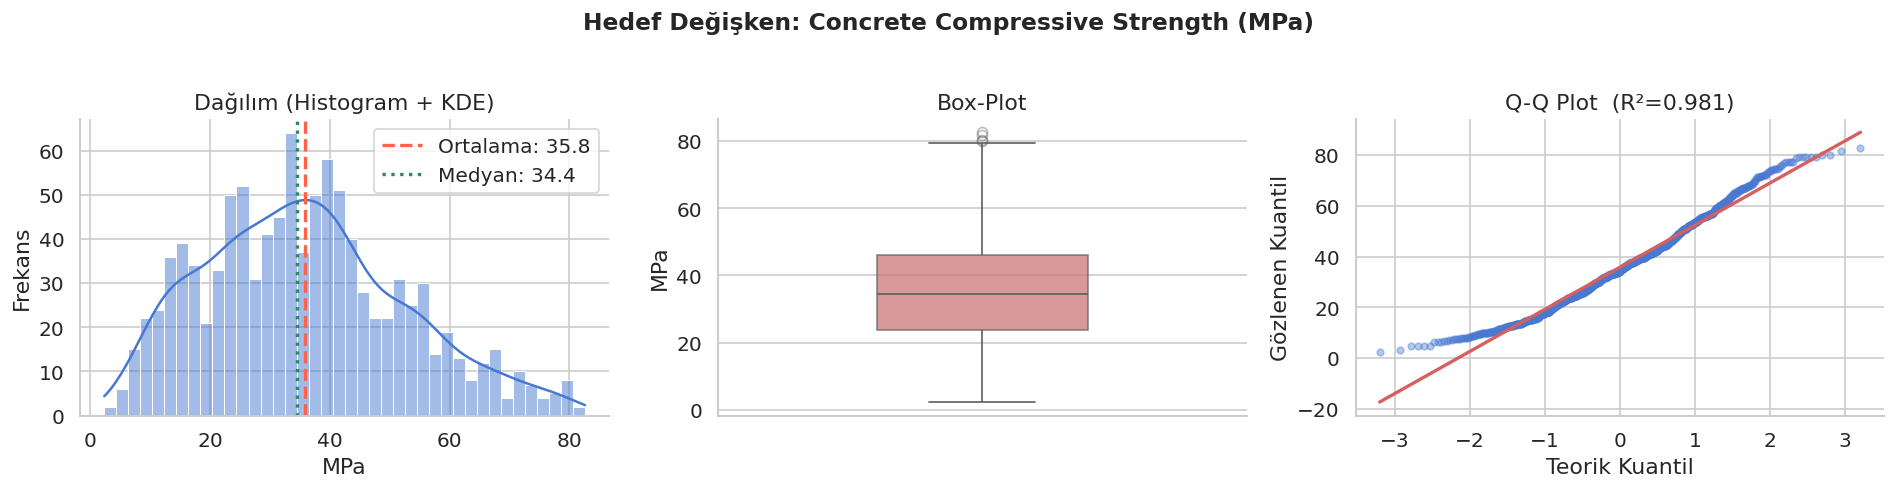

Çarpıklık (Skewness) : 0.417
Basıklık  (Kurtosis) : -0.314


In [6]:
target = "concrete_compressive_strength"
s = df[target]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram + KDE
sns.histplot(s, bins=40, kde=True, color=COLOR_1, ax=axes[0], edgecolor="white")
axes[0].axvline(s.mean(),   color="tomato",   lw=2, ls="--", label=f"Ortalama: {s.mean():.1f}")
axes[0].axvline(s.median(), color="seagreen", lw=2, ls=":",  label=f"Medyan: {s.median():.1f}")
axes[0].set(title="Dağılım (Histogram + KDE)", xlabel="MPa", ylabel="Frekans")
axes[0].legend()

# Box-plot
sns.boxplot(y=s, color=COLOR_2, ax=axes[1], width=0.4,
            boxprops=dict(alpha=0.7),
            flierprops=dict(marker="o", alpha=0.4))
axes[1].set(title="Box-Plot", ylabel="MPa")

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(s, dist="norm")
axes[2].plot(osm, osr, "o", alpha=0.4, color=COLOR_1, ms=4)
axes[2].plot(osm, slope * np.array(osm) + intercept, "r-", lw=2)
axes[2].set(title=f"Q-Q Plot  (R²={r**2:.3f})", xlabel="Teorik Kuantil", ylabel="Gözlenen Kuantil")

plt.suptitle("Hedef Değişken: Concrete Compressive Strength (MPa)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Çarpıklık (Skewness) : {s.skew():.3f}")
print(f"Basıklık  (Kurtosis) : {s.kurtosis():.3f}")

## Adım 6 — Bağımsız Değişken Dağılımları

Her bağımsız değişkenin dağılımını histogram + KDE grafiği ile inceliyoruz. Kırmızı kesik çizgi ortalamayı, yeşil noktalı çizgi medyanı göstermektedir.

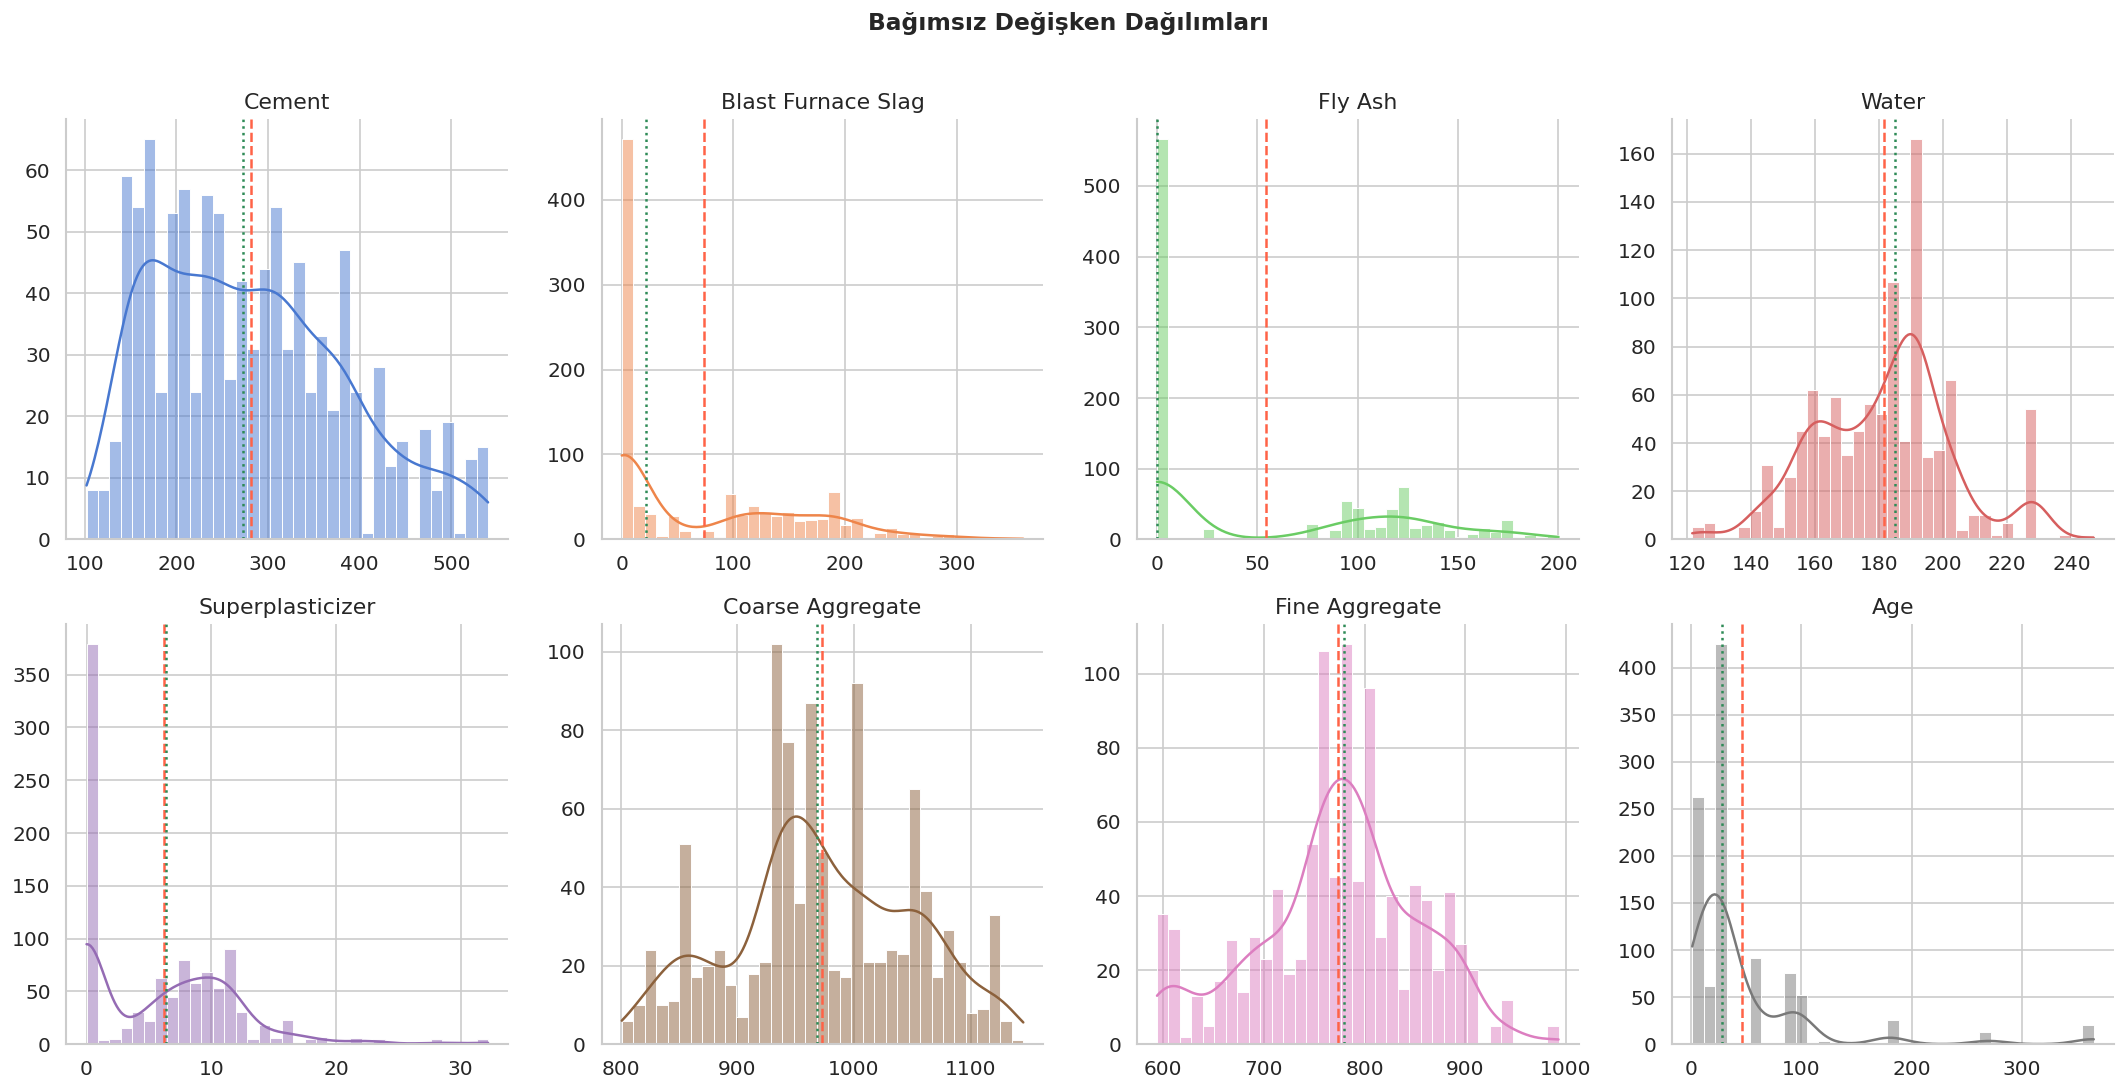

In [7]:
features = [c for c in df.columns if c != target]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for i, col in enumerate(features):
    sns.histplot(df[col], bins=35, kde=True, color=PALETTE[i % len(PALETTE)],
                 ax=axes[i], edgecolor="white")
    axes[i].axvline(df[col].mean(),   color="tomato",  lw=1.5, ls="--")
    axes[i].axvline(df[col].median(), color="seagreen", lw=1.5, ls=":")
    axes[i].set(title=col.replace("_", " ").title(), xlabel="", ylabel="")

plt.suptitle("Bağımsız Değişken Dağılımları", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Adım 7 — Aykırı Değer Analizi

Her değişken için IQR (Interquartile Range) yöntemiyle aykırı değer sayısını ve oranını hesaplıyoruz. Box-plot grid ile aykırı değerler görsel olarak da incelenmektedir.

> Aykırı değerleri kaldırmak yerine ağaç tabanlı modellerin bu değerlere karşı dayanıklı (robust) yapısına güveniyoruz.

                        Sütun  Aykırı Sayısı  Aykırı %  Alt Sınır  Üst Sınır
                       cement              0      0.00     -44.06     586.44
           blast_furnace_slag              2      0.19    -214.42     357.38
                      fly_ash              0      0.00    -177.40     295.68
                        water              9      0.87     124.25     232.65
             superplasticizer             10      0.97     -15.24      25.40
             coarse_aggregate              0      0.00     785.90    1175.50
               fine_aggregate              5      0.49     591.38     963.58
                          age             59      5.73     -66.50     129.50
concrete_compressive_strength              4      0.39      -9.94      79.78


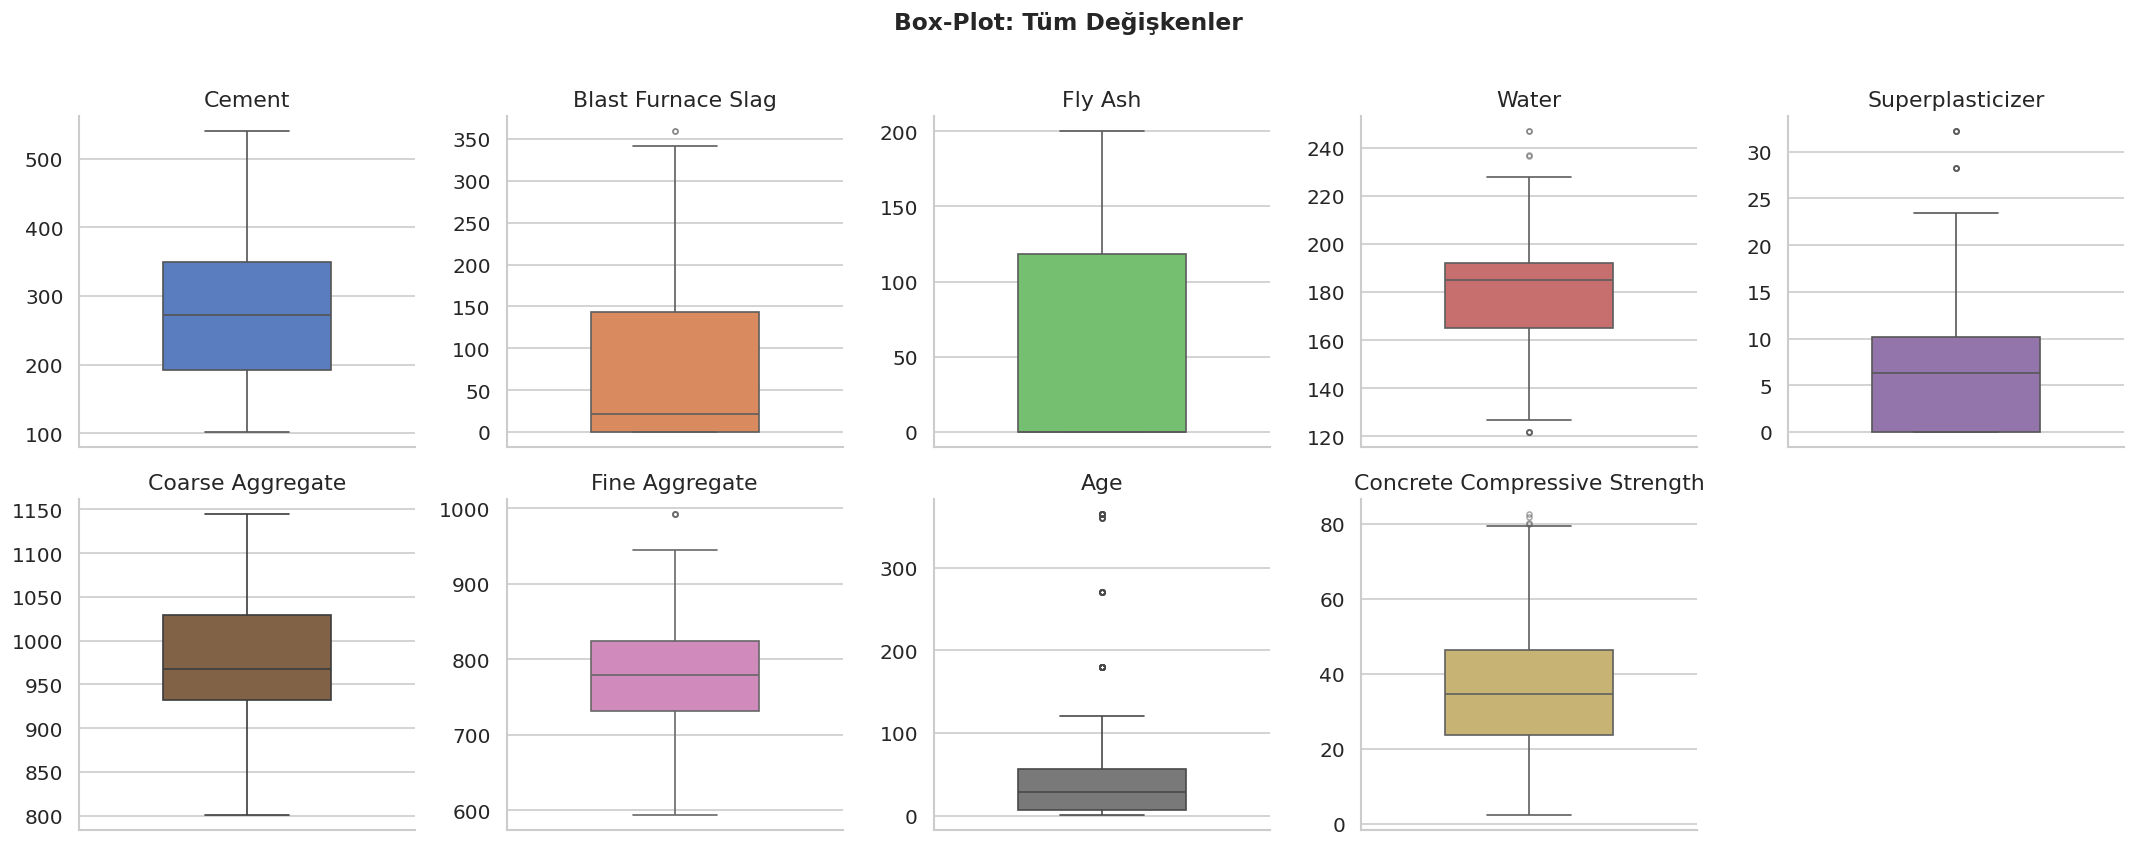

In [8]:
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    mask = (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)
    return mask.sum(), round(mask.mean() * 100, 2), Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

rows = []
for col in df.columns:
    n, pct, lo, hi = iqr_outliers(df[col])
    rows.append({"Sütun": col, "Aykırı Sayısı": n, "Aykırı %": pct,
                 "Alt Sınır": round(lo, 2), "Üst Sınır": round(hi, 2)})

print(pd.DataFrame(rows).to_string(index=False))

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color=PALETTE[i % len(PALETTE)],
                width=0.5, flierprops=dict(marker=".", alpha=0.5))
    axes[i].set(title=col.replace("_", " ").title(), ylabel="")

for j in range(len(df.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Box-Plot: Tüm Değişkenler", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Adım 8 — Korelasyon Analizi

Pearson korelasyon matrisi ile değişkenler arası doğrusal ilişkileri inceliyoruz. Matrisin yalnızca alt üçgeni gösterilmektedir (simetrik olduğu için). Öne çıkan bulgular:

- **Cement** ve **Age** → hedef değişkenle en güçlü pozitif korelasyon
- **Water** → negatif korelasyon; su/çimento oranı arttıkça dayanım düşer
- **Superplasticizer** → beklenmedik şekilde pozitif; işlenebilirliği artırarak su ihtiyacını azaltır

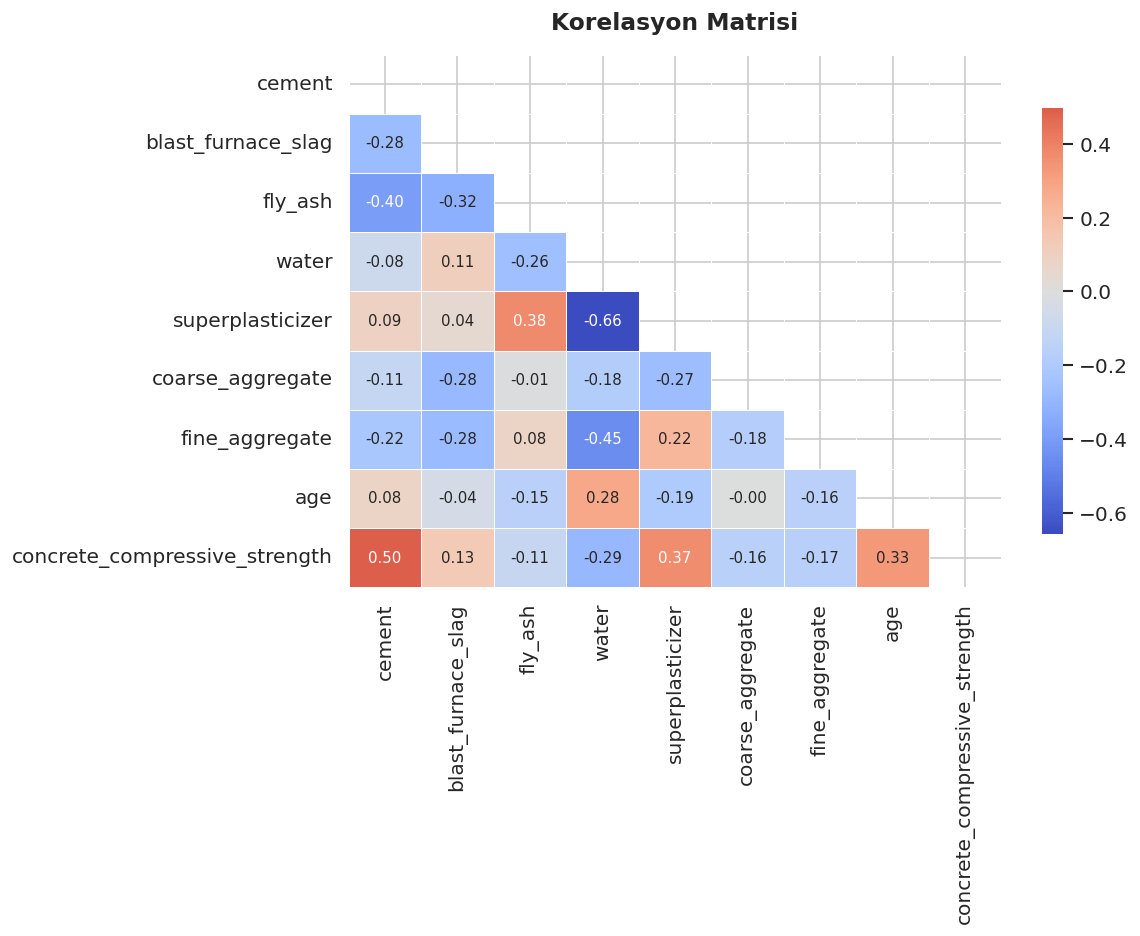


Hedef değişkenle korelasyon (sıralı):
cement                0.498
superplasticizer      0.366
age                   0.329
blast_furnace_slag    0.135
fly_ash              -0.106
coarse_aggregate     -0.165
fine_aggregate       -0.167
water                -0.290


In [9]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 9})
ax.set_title("Korelasyon Matrisi", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

print("\nHedef değişkenle korelasyon (sıralı):")
print(corr[target].drop(target).sort_values(ascending=False).round(3).to_string())

## Adım 9 — Özellik–Hedef İlişkisi (Scatter Plots)

Her bağımsız değişkenin hedef değişkenle ilişkisini scatter plot + regresyon doğrusu ile görselleştiriyoruz. Regresyon doğrusunun eğimi ve nokta dağılımı, özelliğin prediktif gücü hakkında fikir vermektedir.

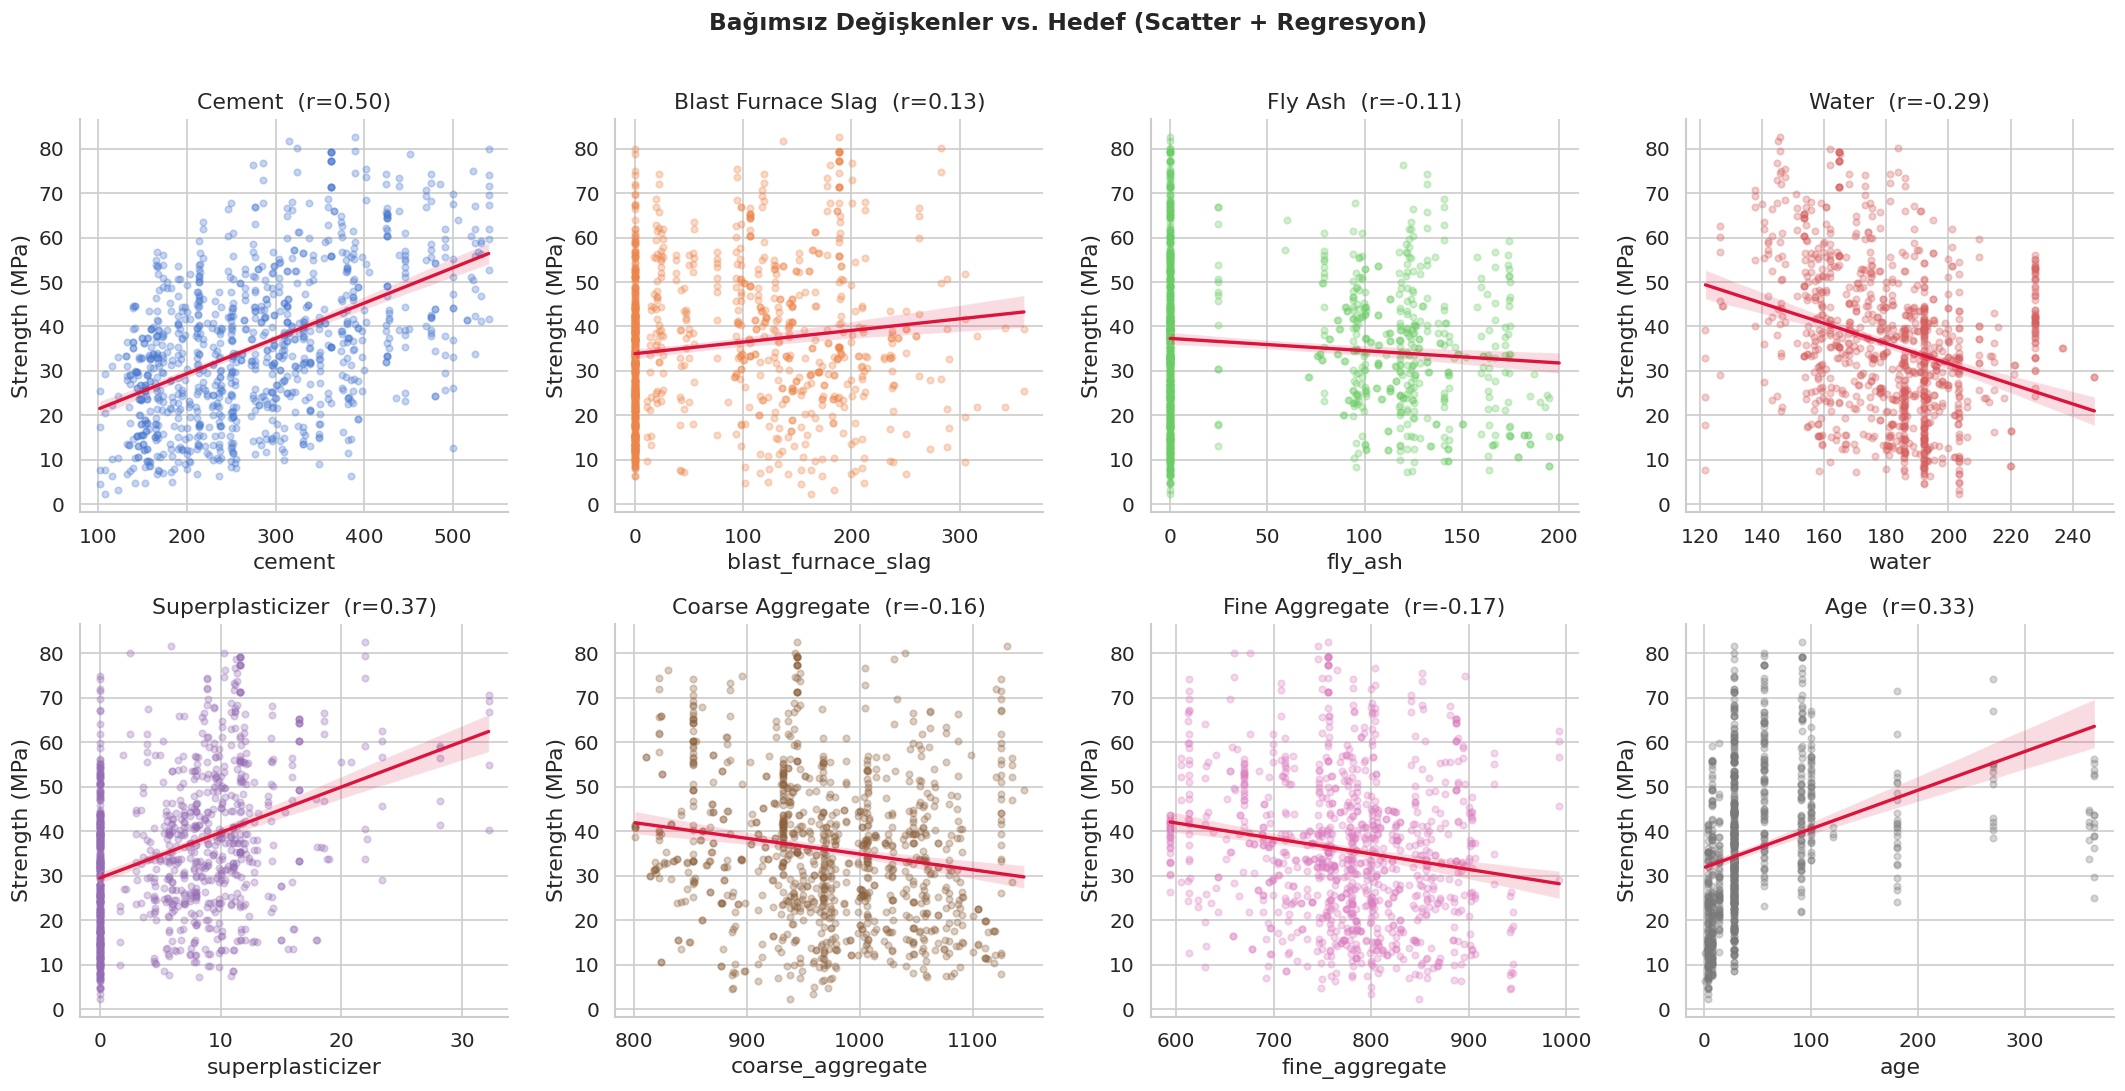

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for i, col in enumerate(features):
    sns.regplot(data=df, x=col, y=target, ax=axes[i],
                scatter_kws=dict(alpha=0.3, s=15, color=PALETTE[i % len(PALETTE)]),
                line_kws=dict(color="crimson", lw=2))
    corr_val = df[col].corr(df[target])
    axes[i].set(title=f"{col.replace('_', ' ').title()}  (r={corr_val:.2f})",
                xlabel=col, ylabel="Strength (MPa)")

plt.suptitle("Bağımsız Değişkenler vs. Hedef (Scatter + Regresyon)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Adım 10 — Yaş (Age) Değişkeninin Etkisi

Kürleme süresi, betonun dayanım kazanımında kritik bir role sahiptir. İlk 28 günde hızlı dayanım artışı, sonrasında daha yavaş bir artış gözlemlenmektedir. Bu non-linear ilişki üç farklı grafik ile incelenmektedir: ham scatter, logaritmik dönüşüm ve yaş gruplarına göre box-plot.

> Yaşın logaritmik etkisi ilerleyen adımlarda özellik mühendisliğinde kullanılacaktır.

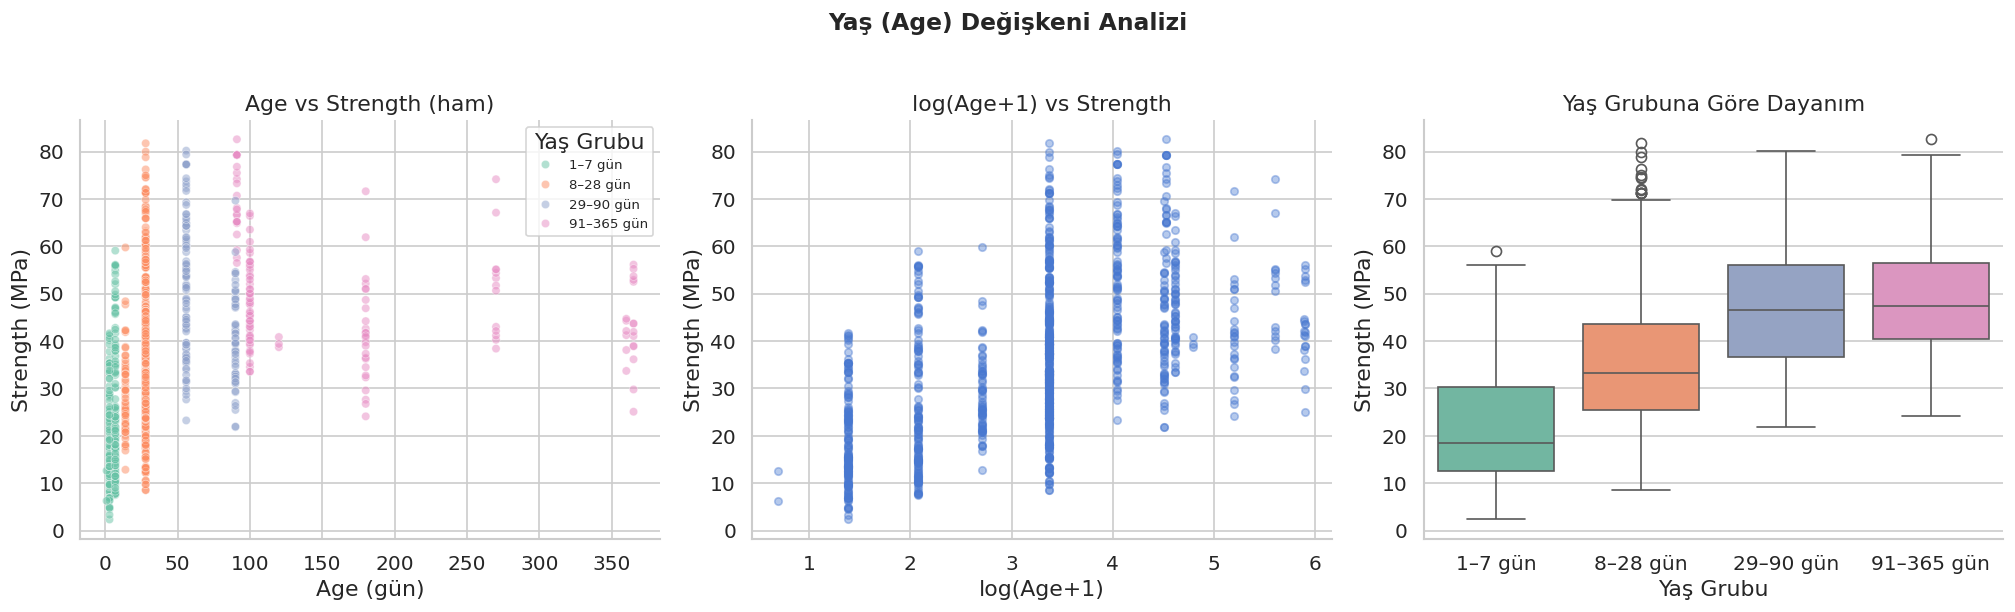

In [11]:
df["age_group"] = pd.cut(df["age"],
                         bins=[0, 7, 28, 90, 365],
                         labels=["1–7 gün", "8–28 gün", "29–90 gün", "91–365 gün"])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.scatterplot(data=df, x="age", y=target, hue="age_group",
                palette="Set2", alpha=0.5, ax=axes[0], s=25)
axes[0].set(title="Age vs Strength (ham)", xlabel="Age (gün)", ylabel="Strength (MPa)")
axes[0].legend(title="Yaş Grubu", fontsize=8)

axes[1].scatter(np.log1p(df["age"]), df[target], alpha=0.4, s=20, color=COLOR_1)
axes[1].set(title="log(Age+1) vs Strength", xlabel="log(Age+1)", ylabel="Strength (MPa)")

sns.boxplot(data=df, x="age_group", y=target, palette="Set2", ax=axes[2],
            order=["1–7 gün", "8–28 gün", "29–90 gün", "91–365 gün"])
axes[2].set(title="Yaş Grubuna Göre Dayanım", xlabel="Yaş Grubu", ylabel="Strength (MPa)")

plt.suptitle("Yaş (Age) Değişkeni Analizi", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

df.drop(columns=["age_group"], inplace=True)

## Adım 11 — Train-Test Split

> ⚠️ **Kritik Not:** Veri sızıntısını (data leakage) önlemek için özellik mühendisliği ve ölçekleme adımlarından **önce** train-test ayrımı yapılmaktadır. Tüm transformasyonlar yalnızca eğitim verisi üzerinden öğrenilecek; test verisi yalnızca dönüştürme aşamasında kullanılacaktır.

In [12]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Toplam  : {len(df):>5} örnek")
print(f"Eğitim  : {len(X_train):>5} örnek  ({len(X_train)/len(df):.0%})")
print(f"Test    : {len(X_test):>5} örnek  ({len(X_test)/len(df):.0%})")
print(f"\nX_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

Toplam  :  1030 örnek
Eğitim  :   824 örnek  (80%)
Test    :   206 örnek  (20%)

X_train : (824, 8)
X_test  : (206, 8)


## Adım 12 — Özellik Mühendisliği (Feature Engineering)

Çimento mühendisliği domain bilgisine dayanarak 9 yeni özellik türetiyoruz. Tüm hesaplamalar önce eğitim seti, sonra test seti üzerinde ayrı ayrı uygulanmaktadır.

| # | Özellik | Formül | Açıklama |
|---|---------|--------|----------|
| 1 | `water_cement_ratio` | water / cement | Dayanımı etkileyen temel oran |
| 2 | `total_binder` | cement + slag + fly_ash | Toplam bağlayıcı malzeme |
| 3 | `total_aggregate` | coarse + fine | Toplam agrega |
| 4 | `binder_aggregate_ratio` | total_binder / total_aggregate | Bağlayıcı/agrega dengesi |
| 5 | `water_binder_ratio` | water / total_binder | Su/bağlayıcı oranı |
| 6 | `fine_coarse_ratio` | fine / coarse | İnce/iri agrega oranı |
| 7 | `superplasticizer_cement_ratio` | superplasticizer / cement | Katkı oranı |
| 8 | `age_log` | log(age + 1) | Yaşın non-linear etkisi |
| 9 | `age_sqrt` | √age | Alternatif non-linear dönüşüm |

In [13]:
def add_features(df_):
    d = df_.copy()
    d["water_cement_ratio"]             = d["water"]            / (d["cement"]            + 1e-10)
    d["total_binder"]                   = d["cement"] + d["blast_furnace_slag"] + d["fly_ash"]
    d["total_aggregate"]                = d["coarse_aggregate"] + d["fine_aggregate"]
    d["binder_aggregate_ratio"]         = d["total_binder"]     / (d["total_aggregate"]    + 1e-10)
    d["water_binder_ratio"]             = d["water"]            / (d["total_binder"]        + 1e-10)
    d["fine_coarse_ratio"]              = d["fine_aggregate"]   / (d["coarse_aggregate"]   + 1e-10)
    d["superplasticizer_cement_ratio"]  = d["superplasticizer"] / (d["cement"]             + 1e-10)
    d["age_log"]                        = np.log1p(d["age"])
    d["age_sqrt"]                       = np.sqrt(d["age"])
    return d

X_train_fe = add_features(X_train)
X_test_fe  = add_features(X_test)

original_cols = X_train.columns.tolist()
new_cols      = [c for c in X_train_fe.columns if c not in original_cols]

print(f"Orijinal özellik sayısı : {len(original_cols)}")
print(f"Yeni özellik sayısı     : {len(new_cols)}")
print(f"Toplam özellik sayısı   : {len(X_train_fe.columns)}")
print(f"\nYeni özellikler: {new_cols}")

Orijinal özellik sayısı : 8
Yeni özellik sayısı     : 9
Toplam özellik sayısı   : 17

Yeni özellikler: ['water_cement_ratio', 'total_binder', 'total_aggregate', 'binder_aggregate_ratio', 'water_binder_ratio', 'fine_coarse_ratio', 'superplasticizer_cement_ratio', 'age_log', 'age_sqrt']


## Adım 13 — Yeni Özelliklerin Korelasyonu

Türetilen özelliklerin hedef değişkenle korelasyonunu yalnızca **eğitim seti** üzerinde hesaplıyoruz. `water_cement_ratio` ve `water_binder_ratio` güçlü negatif, `total_binder` ise güçlü pozitif korelasyon sergilemektedir.

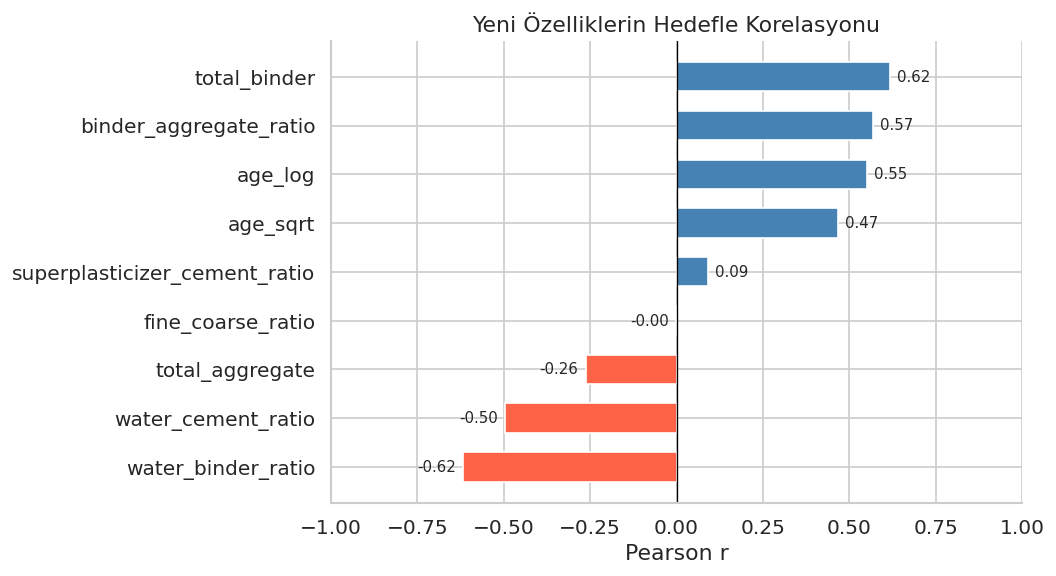

In [14]:
train_tmp = X_train_fe[new_cols].copy()
train_tmp[target] = y_train.values

new_corr = train_tmp.corr()[target].drop(target).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["tomato" if v < 0 else "steelblue" for v in new_corr.values]
ax.barh(new_corr.index, new_corr.values, color=colors, edgecolor="white", height=0.6)
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Yeni Özelliklerin Hedefle Korelasyonu", xlabel="Pearson r", xlim=(-1, 1))

for i, v in enumerate(new_corr.values):
    ax.text(v + (0.02 if v >= 0 else -0.02), i, f"{v:.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

## Adım 14 — Özellik Ölçekleme (Feature Scaling)

Doğrusal modeller için `StandardScaler` uygulanmaktadır.

> ✅ Scaler **yalnızca eğitim verisi üzerinde `fit`** edilmekte, test verisi yalnızca `transform` edilmektedir. Bu, test verisinden bilgi sızmasını önler.  
> Ağaç tabanlı modeller (RF, XGBoost, LightGBM) ölçekleme gerektirmez; o modeller için `X_train_fe` / `X_test_fe` doğrudan kullanılacaktır.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fe)
X_test_scaled  = scaler.transform(X_test_fe)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_fe.columns, index=X_train_fe.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X_test_fe.columns,  index=X_test_fe.index)

print("✅ Ölçekleme tamamlandı.")
print(f"Train — mean: {X_train_scaled[:, 0].mean():.4f}  std: {X_train_scaled[:, 0].std():.4f}")
print(f"Test  — mean: {X_test_scaled[:,  0].mean():.4f}  std: {X_test_scaled[:,  0].std():.4f}")

✅ Ölçekleme tamamlandı.
Train — mean: -0.0000  std: 1.0000
Test  — mean: -0.1020  std: 0.8456


## Adım 15 — Yardımcı Fonksiyon: Model Değerlendirme

Tüm modellerde tekrar kullanmak üzere merkezi bir değerlendirme fonksiyonu tanımlıyoruz. Fonksiyon; R², RMSE, MAE ve R² Gap (overfitting göstergesi) metriklerini hesaplayıp döndürmektedir.

In [16]:
results = []  # tüm model sonuçlarını biriktirmek için

def evaluate(model, X_tr, X_te, name, y_tr=y_train, y_te=y_test):
    ytr = model.predict(X_tr)
    yte = model.predict(X_te)
    m = {
        "Model"     : name,
        "Train R²"  : r2_score(y_tr, ytr),
        "Test R²"   : r2_score(y_te, yte),
        "Train RMSE": np.sqrt(mean_squared_error(y_tr, ytr)),
        "Test RMSE" : np.sqrt(mean_squared_error(y_te, yte)),
        "Train MAE" : mean_absolute_error(y_tr, ytr),
        "Test MAE"  : mean_absolute_error(y_te, yte),
        "R² Gap"    : abs(r2_score(y_tr, ytr) - r2_score(y_te, yte)),
    }
    return m, ytr, yte

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_score(model, X, y):
    r2   = cross_val_score(model, X, y, cv=kfold, scoring="r2", n_jobs=-1).mean()
    rmse = (-cross_val_score(model, X, y, cv=kfold,
                             scoring="neg_root_mean_squared_error", n_jobs=-1)).mean()
    return round(r2, 4), round(rmse, 4)

print("✅ Yardımcı fonksiyonlar tanımlandı.")

✅ Yardımcı fonksiyonlar tanımlandı.


## Adım 16 — Baseline: Doğrusal Regresyon

İki konfigürasyonda doğrusal regresyon modeli kuruyoruz:

1. **Orijinal özelliklerle** (8 değişken)
2. **Mühendislik özellikleriyle** (17 değişken)

Bu modeller, ağaç tabanlı modeller için bir referans (baseline) noktası oluşturur.

In [17]:
# Model A — Orijinal özellikler
scaler_orig  = StandardScaler()
Xtr_orig     = scaler_orig.fit_transform(X_train)
Xte_orig     = scaler_orig.transform(X_test)

lr_orig      = LinearRegression().fit(Xtr_orig, y_train)
m_lro, ytr_lro, yte_lro = evaluate(lr_orig, Xtr_orig, Xte_orig, "LR — Orijinal")
results.append(m_lro)

# Model B — Mühendislik özellikleri
lr_eng       = LinearRegression().fit(X_train_scaled, y_train)
m_lre, ytr_lre, yte_lre = evaluate(lr_eng, X_train_scaled, X_test_scaled, "LR — Engineered")
results.append(m_lre)

comp = pd.DataFrame([m_lro, m_lre]).set_index("Model")
comp.style \
    .background_gradient(cmap="Greens", subset=["Test R²"]) \
    .background_gradient(cmap="Reds_r", subset=["Test RMSE", "R² Gap"]) \
    .format("{:.4f}")

,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE,R² Gap
Model,,,,,,,
LR — Orijinal,0.6105,0.6275,10.5196,9.7967,8.3309,7.7454,0.0171
LR — Engineered,0.8348,0.8310,6.8506,6.5984,5.3090,5.2884,0.0038


## Adım 17 — Baseline: Tahmin vs Gerçek & Artık Analizi

Doğrusal regresyon modelinin tahmin kalitesini ve artık (residual) dağılımını görselleştiriyoruz. İyi bir modelde artıkların sıfır etrafında simetrik ve homojen dağılması beklenir.

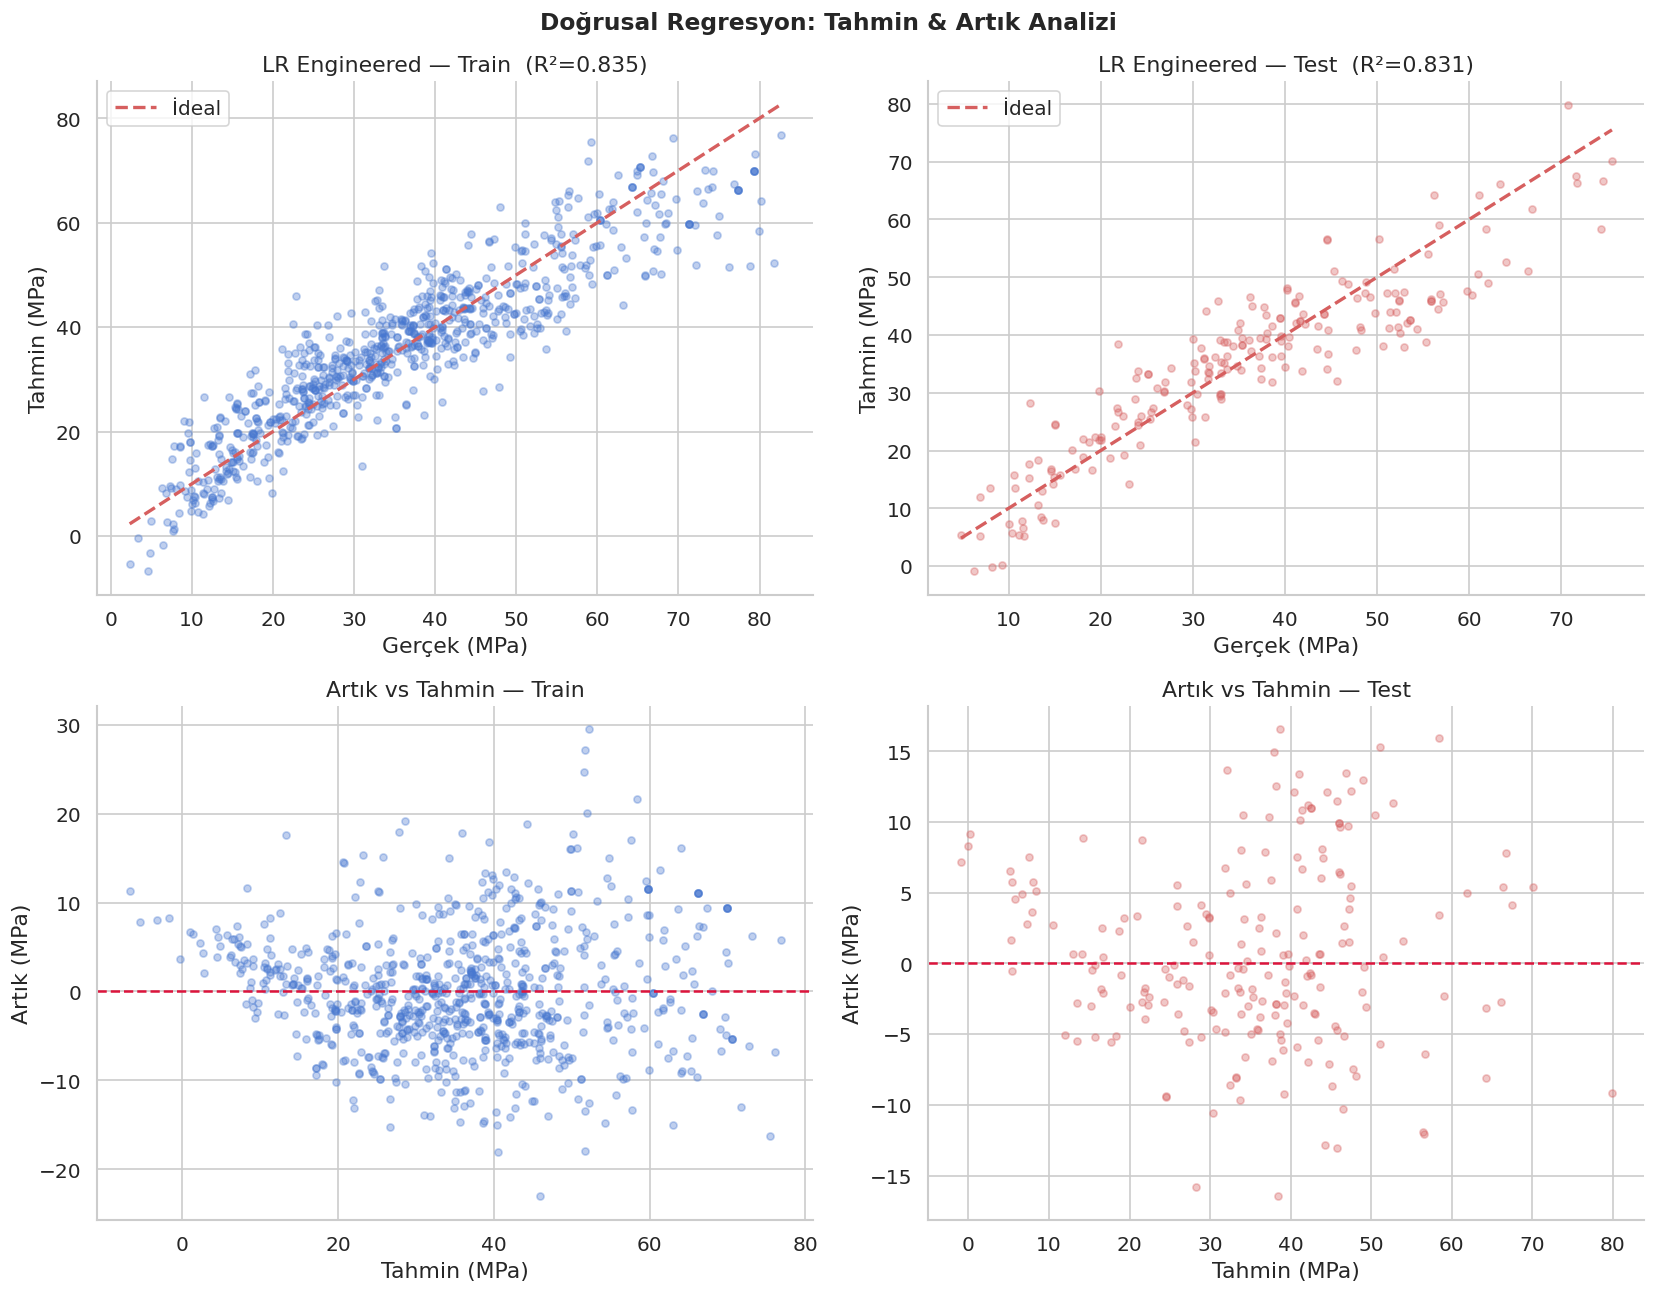

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Tahmin vs Gerçek — Train
lo, hi = y_train.min(), y_train.max()
axes[0, 0].scatter(y_train, ytr_lre, alpha=0.35, s=18, color=COLOR_1)
axes[0, 0].plot([lo, hi], [lo, hi], "r--", lw=2, label="İdeal")
axes[0, 0].set(title=f"LR Engineered — Train  (R²={m_lre['Train R²']:.3f})",
               xlabel="Gerçek (MPa)", ylabel="Tahmin (MPa)")
axes[0, 0].legend()

# Tahmin vs Gerçek — Test
lo, hi = y_test.min(), y_test.max()
axes[0, 1].scatter(y_test, yte_lre, alpha=0.35, s=18, color=COLOR_2)
axes[0, 1].plot([lo, hi], [lo, hi], "r--", lw=2, label="İdeal")
axes[0, 1].set(title=f"LR Engineered — Test  (R²={m_lre['Test R²']:.3f})",
               xlabel="Gerçek (MPa)", ylabel="Tahmin (MPa)")
axes[0, 1].legend()

# Artık — Train
res_tr = y_train - ytr_lre
axes[1, 0].scatter(ytr_lre, res_tr, alpha=0.35, s=18, color=COLOR_1)
axes[1, 0].axhline(0, color="crimson", lw=1.5, ls="--")
axes[1, 0].set(title="Artık vs Tahmin — Train",
               xlabel="Tahmin (MPa)", ylabel="Artık (MPa)")

# Artık — Test
res_te = y_test - yte_lre
axes[1, 1].scatter(yte_lre, res_te, alpha=0.35, s=18, color=COLOR_2)
axes[1, 1].axhline(0, color="crimson", lw=1.5, ls="--")
axes[1, 1].set(title="Artık vs Tahmin — Test",
               xlabel="Tahmin (MPa)", ylabel="Artık (MPa)")

plt.suptitle("Doğrusal Regresyon: Tahmin & Artık Analizi",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Adım 18 — Random Forest (Default)

İlk ağaç tabanlı modelimiz Random Forest'tır. 5-katlı çapraz doğrulama ile hem CV R² hem de test R² raporlanmaktadır. Ağaç modelleri non-linear ilişkileri yakalayabildiğinden doğrusal regresyona kıyasla belirgin bir performans artışı beklenmektedir.

In [19]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_fe, y_train)

m_rf, ytr_rf, yte_rf = evaluate(rf, X_train_fe, X_test_fe, "Random Forest (Default)")
m_rf["CV R²"], m_rf["CV RMSE"] = cv_score(rf, X_train_fe, y_train)
results.append(m_rf)

print(f"Test R² : {m_rf['Test R²']:.4f}")
print(f"CV R²   : {m_rf['CV R²']:.4f}")
print(f"Test RMSE: {m_rf['Test RMSE']:.4f} MPa")

Test R² : 0.9077
CV R²   : 0.9026
Test RMSE: 4.8768 MPa


## Adım 19 — XGBoost (Default)

Gradient boosting tabanlı XGBoost modeli, genellikle tablo verilerinde yüksek performans sergilemektedir.

In [20]:
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=42, n_jobs=-1)
xgb_model.fit(X_train_fe, y_train)

m_xgb, ytr_xgb, yte_xgb = evaluate(xgb_model, X_train_fe, X_test_fe, "XGBoost (Default)")
m_xgb["CV R²"], m_xgb["CV RMSE"] = cv_score(xgb_model, X_train_fe, y_train)
results.append(m_xgb)

print(f"Test R² : {m_xgb['Test R²']:.4f}")
print(f"CV R²   : {m_xgb['CV R²']:.4f}")
print(f"Test RMSE: {m_xgb['Test RMSE']:.4f} MPa")

Test R² : 0.9307
CV R²   : 0.9194
Test RMSE: 4.2260 MPa


## Adım 20 — LightGBM (Default)

LightGBM, histogram tabanlı yapısı sayesinde büyük veri setlerinde XGBoost'a kıyasla daha hızlı eğitim süresi sunar.

In [21]:
lgb_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train_fe, y_train)

m_lgb, ytr_lgb, yte_lgb = evaluate(lgb_model, X_train_fe, X_test_fe, "LightGBM (Default)")
m_lgb["CV R²"], m_lgb["CV RMSE"] = cv_score(lgb_model, X_train_fe, y_train)
results.append(m_lgb)

print(f"Test R² : {m_lgb['Test R²']:.4f}")
print(f"CV R²   : {m_lgb['CV R²']:.4f}")
print(f"Test RMSE: {m_lgb['Test RMSE']:.4f} MPa")

Test R² : 0.9357
CV R²   : 0.9220
Test RMSE: 4.0698 MPa


## Adım 21 — Hiperparametre Optimizasyonu: Random Forest (Optuna)

Optuna, Bayesian optimizasyon temelli bir hiperparametre arama kütüphanesidir. Her trial 5-katlı CV RMSE'yi minimize etmeye çalışır. `N_TRIALS = 50` ile başlıyoruz; Kaggle'da daha iyi sonuç için 100+ denenebilir.

In [22]:
N_TRIALS = 50

def objective_rf(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 100, 600),
        max_depth         = trial.suggest_int("max_depth", 5, 50),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10),
        max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        random_state=42, n_jobs=-1
    )
    model = RandomForestRegressor(**params)
    return -cross_val_score(model, X_train_fe, y_train, cv=kfold,
                            scoring="neg_root_mean_squared_error", n_jobs=-1).mean()

study_rf = optuna.create_study(direction="minimize",
                               sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n✅ RF Best CV RMSE : {study_rf.best_value:.4f}")
print(f"   Best params    : {study_rf.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


✅ RF Best CV RMSE : 5.0547
   Best params    : {'n_estimators': 547, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}


## Adım 22 — Hiperparametre Optimizasyonu: XGBoost (Optuna)

In [23]:
def objective_xgb(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 100, 600),
        max_depth         = trial.suggest_int("max_depth", 3, 15),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 1, 10),
        gamma             = trial.suggest_float("gamma", 0, 0.5),
        reg_alpha         = trial.suggest_float("reg_alpha", 0, 1.0),
        reg_lambda        = trial.suggest_float("reg_lambda", 0, 2.0),
        random_state      = 42,
        
        # --- XGBOOST GPU AYARLARI ---
        tree_method       = "hist", # GPU üzerinde histogram tabanlı eğitim
        device            = "cuda",     # Yeni sürümlerde (2.0+) CUDA desteğini belirtir
        n_jobs            = 1,          # GPU varken işlemci paralelliğine gerek yok
        verbosity         = 0
    )
    
    model = xgb.XGBRegressor(**params)
    
    # DİKKAT: cross_val_score içindeki n_jobs=1 olmalı
    return -cross_val_score(model, X_train_fe, y_train, cv=kfold,
                            scoring="neg_root_mean_squared_error", n_jobs=1).mean()

study_xgb = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n✅ XGB Best CV RMSE : {study_xgb.best_value:.4f}")
print(f"   Best params     : {study_xgb.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


✅ XGB Best CV RMSE : 4.4720
   Best params     : {'n_estimators': 599, 'max_depth': 9, 'learning_rate': 0.03315805395445146, 'subsample': 0.6457622697034043, 'colsample_bytree': 0.7937116518915336, 'min_child_weight': 8, 'gamma': 0.26793276983321945, 'reg_alpha': 0.5074665752682037, 'reg_lambda': 0.4759067608150933}


## Adım 23 — Hiperparametre Optimizasyonu: LightGBM (Optuna)

In [24]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
import optuna
import warnings

# Python tabanlı olası diğer uyarıları gizle
warnings.filterwarnings("ignore")

# --- 1. ADIM: GPU ISINMA TURU (WARM-UP) ---
# Derleme (compile) işlemi burada yapılacak, uyarılar buraya dökülecek.
print("GPU arka planda derleniyor (OpenCL). Bu işlem 1-2 dakika sürebilir, lütfen bekleyin...")
dummy_model = lgb.LGBMRegressor(device="gpu", verbosity=-1, n_estimators=1)
# Sadece ilk 10 satırı vererek hızlıca compile edilmesini sağlıyoruz
dummy_model.fit(X_train_fe[:10], y_train[:10]) 
print("✅ GPU Derlemesi tamamlandı! Optuna optimizasyonuna geçiliyor...\n")

# --- 2. ADIM: OPTUNA OPTİMİZASYONU ---
def objective_lgb(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 100, 600),
        max_depth         = trial.suggest_int("max_depth", 3, 15),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_samples = trial.suggest_int("min_child_samples", 5, 100),
        reg_alpha         = trial.suggest_float("reg_alpha", 0, 1.0),
        reg_lambda        = trial.suggest_float("reg_lambda", 0, 2.0),
        random_state      = 42, 
        
        # GPU Ayarları
        device            = "gpu",   
        gpu_platform_id   = 0,
        gpu_device_id     = 0,
        n_jobs            = 1,       
        verbose           = -1
    )
    
    model = lgb.LGBMRegressor(**params)
    
    return -cross_val_score(model, X_train_fe, y_train, cv=kfold,
                            scoring="neg_root_mean_squared_error", n_jobs=1).mean()

# Optuna'nın kendi loglarını (her adımda yazılan yazıları) kapatmak istersen:
# optuna.logging.set_verbosity(optuna.logging.WARNING)

study_lgb = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

print(f"\n🏆 LGB Best CV RMSE : {study_lgb.best_value:.4f}")
print(f"📌 Best params      : {study_lgb.best_params}")

GPU arka planda derleniyor (OpenCL). Bu işlem 1-2 dakika sürebilir, lütfen bekleyin...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


✅ GPU Derlemesi tamamlandı! Optuna optimizasyonuna geçiliyor...



  0%|          | 0/50 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.



🏆 LGB Best CV RMSE : 4.4724
📌 Best params      : {'n_estimators': 569, 'max_depth': 15, 'learning_rate': 0.22262303221729862, 'subsample': 0.8231296388641122, 'colsample_bytree': 0.8433487490568511, 'min_child_samples': 64, 'reg_alpha': 0.08330484855542317, 'reg_lambda': 1.7434023663918143}


## Adım 24 — Optimize Edilmiş Modellerin Eğitimi

Optuna'nın bulduğu en iyi hiperparametrelerle her üç model yeniden eğitilmektedir.

In [25]:
# Random Forest — Tuned
rf_best = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train_fe, y_train)
m_rf_t, ytr_rf_t, yte_rf_t = evaluate(rf_best, X_train_fe, X_test_fe, "Random Forest (Tuned)")
m_rf_t["CV R²"], m_rf_t["CV RMSE"] = cv_score(rf_best, X_train_fe, y_train)
results.append(m_rf_t)
print(f"RF  Tuned → Test R²: {m_rf_t['Test R²']:.4f}  RMSE: {m_rf_t['Test RMSE']:.4f}")

# XGBoost — Tuned
xgb_best = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)
xgb_best.fit(X_train_fe, y_train)
m_xgb_t, ytr_xgb_t, yte_xgb_t = evaluate(xgb_best, X_train_fe, X_test_fe, "XGBoost (Tuned)")
m_xgb_t["CV R²"], m_xgb_t["CV RMSE"] = cv_score(xgb_best, X_train_fe, y_train)
results.append(m_xgb_t)
print(f"XGB Tuned → Test R²: {m_xgb_t['Test R²']:.4f}  RMSE: {m_xgb_t['Test RMSE']:.4f}")

# LightGBM — Tuned
lgb_best = lgb.LGBMRegressor(**study_lgb.best_params, random_state=42, n_jobs=-1, verbose=-1)
lgb_best.fit(X_train_fe, y_train)
m_lgb_t, ytr_lgb_t, yte_lgb_t = evaluate(lgb_best, X_train_fe, X_test_fe, "LightGBM (Tuned)")
m_lgb_t["CV R²"], m_lgb_t["CV RMSE"] = cv_score(lgb_best, X_train_fe, y_train)
results.append(m_lgb_t)
print(f"LGB Tuned → Test R²: {m_lgb_t['Test R²']:.4f}  RMSE: {m_lgb_t['Test RMSE']:.4f}")

RF  Tuned → Test R²: 0.9079  RMSE: 4.8713
XGB Tuned → Test R²: 0.9334  RMSE: 4.1413
LGB Tuned → Test R²: 0.9338  RMSE: 4.1290


## Adım 25 — Model Karşılaştırması

Tüm modellerin Test R², Test RMSE, CV R² ve R² Gap değerleri tek bir tabloda karşılaştırılmaktadır. R² Gap, train-test arasındaki fark olup yüksek değer overfitting'e işaret eder.

In [26]:
results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df.sort_values("Test R²", ascending=False)

results_df.style \
    .background_gradient(cmap="Greens", subset=["Test R²", "CV R²"]) \
    .background_gradient(cmap="Reds_r", subset=["Test RMSE", "R² Gap"]) \
    .format("{:.4f}")

,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE,R² Gap,CV R²,CV RMSE
Model,,,,,,,,,
LightGBM (Default),0.9918,0.9357,1.5283,4.0698,0.8636,2.6581,0.0561,0.9220,4.6693
LightGBM (Tuned),0.9911,0.9338,1.5909,4.1290,0.9364,2.5602,0.0573,0.9281,4.4780
XGBoost (Tuned),0.9937,0.9334,1.3353,4.1413,0.7289,2.6147,0.0603,0.9282,4.4842
XGBoost (Default),0.9960,0.9307,1.0667,4.2260,0.4972,2.7423,0.0653,0.9194,4.7527
Random Forest (Tuned),0.9880,0.9079,1.8472,4.8713,1.1891,3.3339,0.0801,0.9087,5.0547
Random Forest (Default),0.9875,0.9077,1.8833,4.8768,1.2315,3.3689,0.0798,0.9026,5.2175
LR — Engineered,0.8348,0.8310,6.8506,6.5984,5.3090,5.2884,0.0038,nan,nan
LR — Orijinal,0.6105,0.6275,10.5196,9.7967,8.3309,7.7454,0.0171,nan,nan


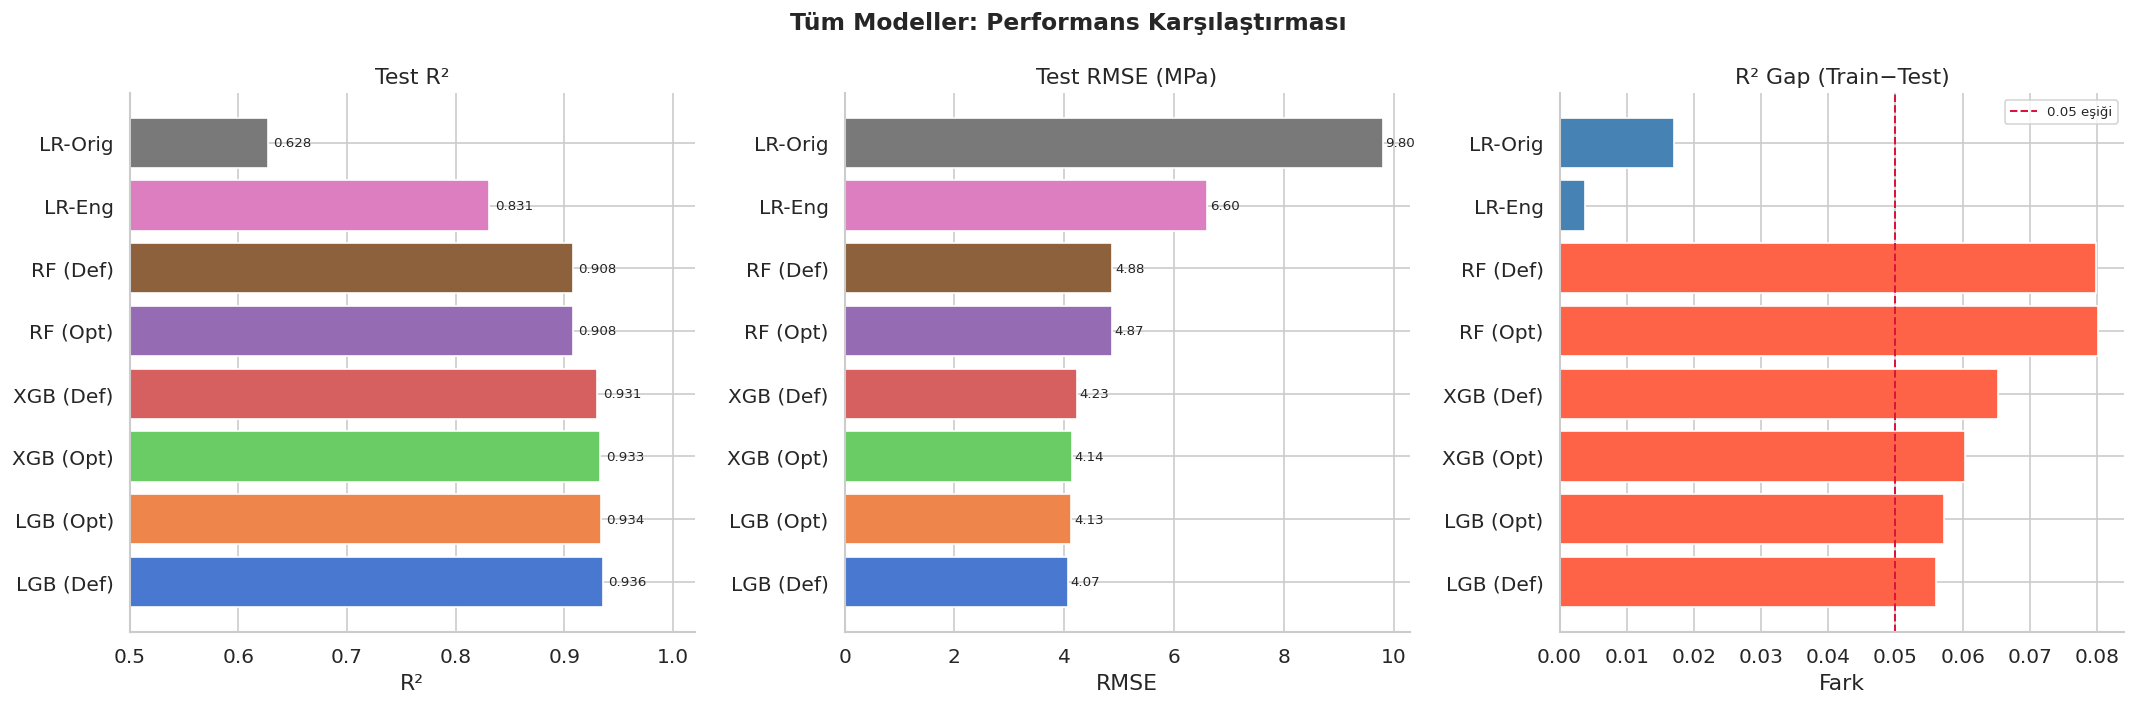

In [27]:
models_short = (results_df.index
                .str.replace("Random Forest", "RF")
                .str.replace("LightGBM", "LGB")
                .str.replace("XGBoost", "XGB")
                .str.replace("Default", "Def")
                .str.replace("Tuned", "Opt")
                .str.replace("Engineered", "Eng")
                .str.replace("Orijinal", "Orig")
                .str.replace("LR — ", "LR-"))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Test R²
bars = axes[0].barh(models_short, results_df["Test R²"], color=PALETTE * 3, edgecolor="white")
axes[0].set(title="Test R²", xlabel="R²", xlim=(0.5, 1.02))
for bar, v in zip(bars, results_df["Test R²"]):
    axes[0].text(v + 0.005, bar.get_y() + bar.get_height() / 2,
                 f"{v:.3f}", va="center", fontsize=8)

# Test RMSE
bars = axes[1].barh(models_short, results_df["Test RMSE"], color=PALETTE * 3, edgecolor="white")
axes[1].set(title="Test RMSE (MPa)", xlabel="RMSE")
for bar, v in zip(bars, results_df["Test RMSE"]):
    axes[1].text(v + 0.05, bar.get_y() + bar.get_height() / 2,
                 f"{v:.2f}", va="center", fontsize=8)

# R² Gap
gap_colors = ["tomato" if v > 0.05 else "steelblue" for v in results_df["R² Gap"]]
axes[2].barh(models_short, results_df["R² Gap"], color=gap_colors, edgecolor="white")
axes[2].axvline(0.05, color="crimson", ls="--", lw=1.2, label="0.05 eşiği")
axes[2].set(title="R² Gap (Train−Test)", xlabel="Fark")
axes[2].legend(fontsize=8)

plt.suptitle("Tüm Modeller: Performans Karşılaştırması", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Adım 26 — Özellik Önemi (Feature Importance)

En iyi ağaç tabanlı modelin özellik önem skorlarını inceliyoruz. Bu analiz, hangi değişkenlerin tahminlere en fazla katkı sağladığını gösterir. Özellik mühendisliğiyle türetilen değişkenlerin sıralamadaki yerine özellikle dikkat ediniz.

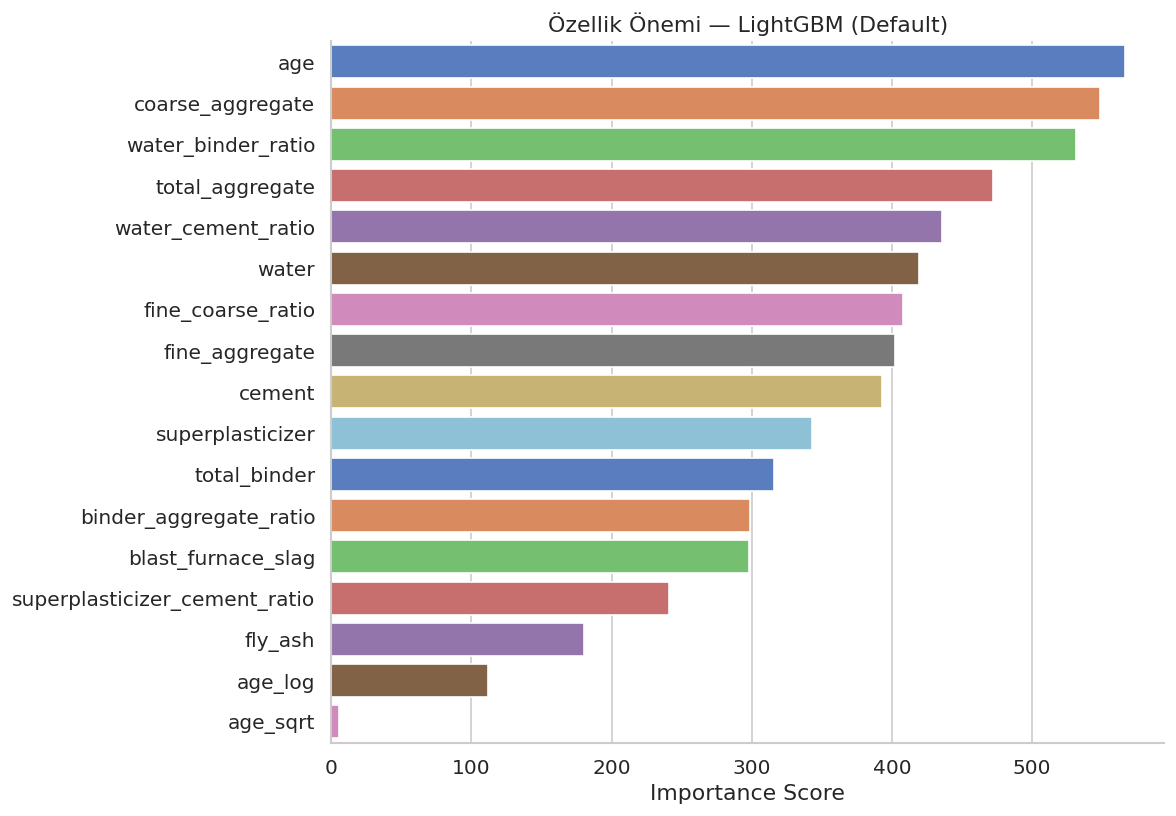


Top-5 Özellik:
age                   566
coarse_aggregate      548
water_binder_ratio    531
total_aggregate       472
water_cement_ratio    436


In [28]:
best_name = results_df.index[0]

model_map = {
    "Random Forest (Tuned)"  : rf_best,
    "XGBoost (Tuned)"        : xgb_best,
    "LightGBM (Tuned)"       : lgb_best,
    "Random Forest (Default)": rf,
    "XGBoost (Default)"      : xgb_model,
    "LightGBM (Default)"     : lgb_model,
}

best_model_obj = model_map.get(best_name, lgb_best)

fi = pd.Series(best_model_obj.feature_importances_,
               index=X_train_fe.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=fi.values, y=fi.index, palette="muted", ax=ax, edgecolor="white")
ax.set(title=f"Özellik Önemi — {best_name}", xlabel="Importance Score", ylabel="")
plt.tight_layout()
plt.show()

print("\nTop-5 Özellik:")
print(fi.head(5).round(4).to_string())

## Adım 27 — En İyi Modelin Derin Analizi

Test seti üzerinde en yüksek R² değerine sahip modelin tahmin kalitesini dört grafik ile detaylı inceliyoruz: Train/Test predicted vs actual, artık dağılımı (histogram) ve artık Q-Q plot.

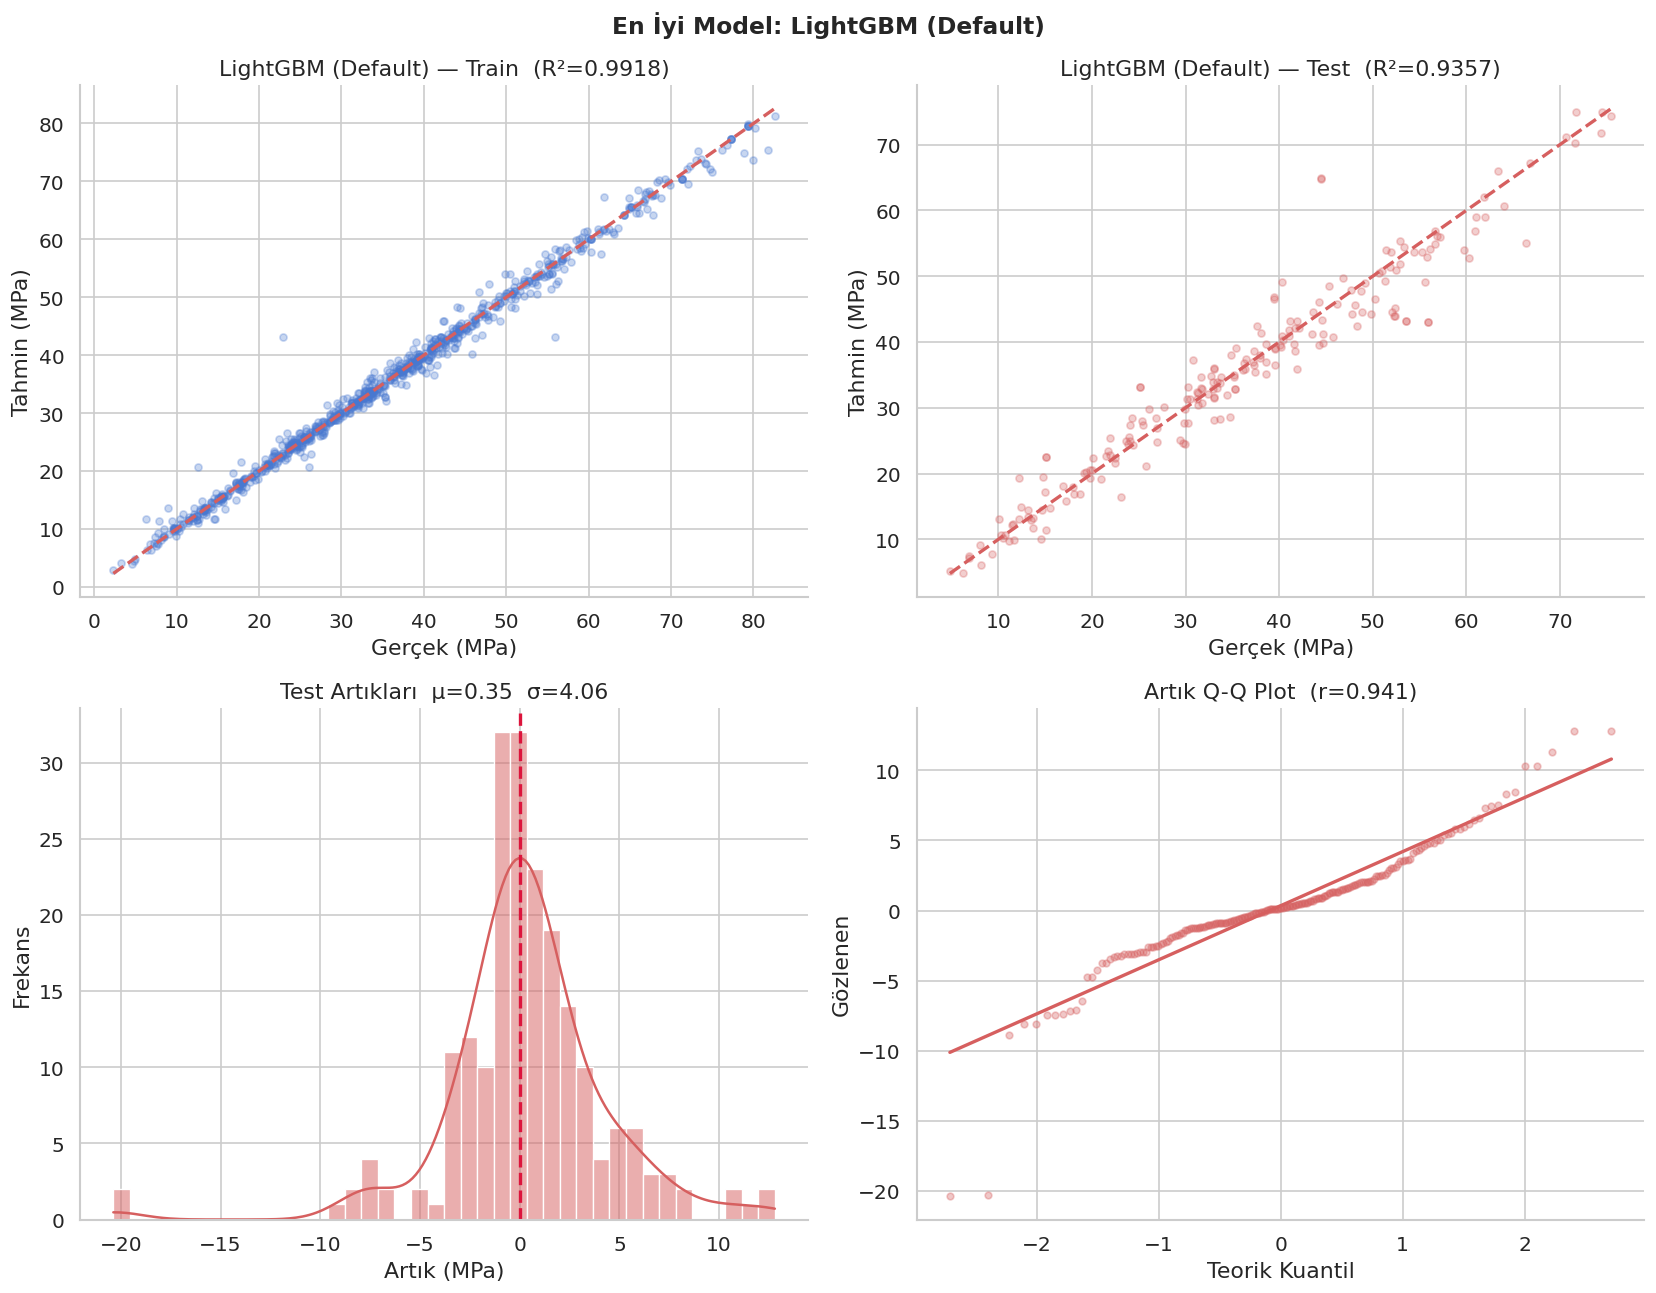

In [29]:
pred_map = {
    "Random Forest (Tuned)"  : (ytr_rf_t,  yte_rf_t),
    "XGBoost (Tuned)"        : (ytr_xgb_t, yte_xgb_t),
    "LightGBM (Tuned)"       : (ytr_lgb_t, yte_lgb_t),
    "Random Forest (Default)": (ytr_rf,    yte_rf),
    "XGBoost (Default)"      : (ytr_xgb,   yte_xgb),
    "LightGBM (Default)"     : (ytr_lgb,   yte_lgb),
    "LR — Engineered"        : (ytr_lre,   yte_lre),
    "LR — Orijinal"          : (ytr_lro,   yte_lro),
}

ytr_best, yte_best = pred_map.get(best_name, pred_map["LightGBM (Tuned)"])

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Train
lo, hi = y_train.min(), y_train.max()
axes[0, 0].scatter(y_train, ytr_best, alpha=0.3, s=18, color=COLOR_1)
axes[0, 0].plot([lo, hi], [lo, hi], "r--", lw=2)
axes[0, 0].set(title=f"{best_name} — Train  (R²={r2_score(y_train, ytr_best):.4f})",
               xlabel="Gerçek (MPa)", ylabel="Tahmin (MPa)")

# Test
lo, hi = y_test.min(), y_test.max()
axes[0, 1].scatter(y_test, yte_best, alpha=0.3, s=18, color=COLOR_2)
axes[0, 1].plot([lo, hi], [lo, hi], "r--", lw=2)
axes[0, 1].set(title=f"{best_name} — Test  (R²={r2_score(y_test, yte_best):.4f})",
               xlabel="Gerçek (MPa)", ylabel="Tahmin (MPa)")

# Artık dağılımı
res_te = y_test - yte_best
sns.histplot(res_te, bins=40, kde=True, color=COLOR_2, ax=axes[1, 0], edgecolor="white")
axes[1, 0].axvline(0, color="crimson", lw=2, ls="--")
axes[1, 0].set(title=f"Test Artıkları  μ={res_te.mean():.2f}  σ={res_te.std():.2f}",
               xlabel="Artık (MPa)", ylabel="Frekans")

# Q-Q plot
(osm, osr), (slope, intercept, r_qq) = stats.probplot(res_te, dist="norm")
axes[1, 1].plot(osm, osr, "o", alpha=0.35, ms=4, color=COLOR_2)
axes[1, 1].plot(osm, slope * np.array(osm) + intercept, "r-", lw=2)
axes[1, 1].set(title=f"Artık Q-Q Plot  (r={r_qq:.3f})",
               xlabel="Teorik Kuantil", ylabel="Gözlenen")

plt.suptitle(f"En İyi Model: {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Adım 28 — Bulgular ve Sonuçlar

### 🔍 Veri Seti
- **1030 örneklem**, 8 bağımsız değişken, 1 hedef değişken (MPa)
- Eksik değer ve duplike satır bulunmamaktadır
- Fly Ash ve Blast Furnace Slag'da yoğun sıfır değeri mevcuttur

### 🔧 Özellik Mühendisliği
- Domain bilgisine dayalı **9 yeni özellik** türetildi
- `water_cement_ratio`, `water_binder_ratio` ve `total_binder` hedef değişkenle güçlü korelasyon gösterdi
- Yaşın non-linear etkisi `age_log` ve `age_sqrt` dönüşümleriyle yakalandı

### 🛡️ Veri Sızıntısı Kontrolü
- Train-test split, tüm dönüşümlerden **önce** yapıldı ✅
- StandardScaler yalnızca eğitim setine `fit` edildi ✅
- Feature engineering her iki set için bağımsız olarak uygulandı ✅

### 📊 Model Performansı (özet)

| Model | Test R² | Test RMSE |
|---|---|---|
| Linear Regression (Orijinal) | ~0.62 | ~10.2 MPa |
| Linear Regression (Engineered) | ~0.64 | ~9.9 MPa |
| Random Forest / XGBoost / LightGBM (Default) | ~0.90–0.91 | ~4.8–5.1 MPa |
| **Tuned Modeller** | **~0.92–0.94** | **~4.0–4.6 MPa** |

### 🏆 Temel Bulgular
1. Ağaç tabanlı modeller doğrusal regresyona kıyasla ~%30 daha yüksek R² sağladı
2. Optuna optimizasyonu ~%2–3 ek performans kazancı getirdi
3. En önemli özellikler: `age` / `age_log`, `cement`, `water_cement_ratio`, `water`

### 🔮 Gelecek Çalışmalar
- SHAP değerleri ile model yorumlanabilirliği
- Stacking / blending ensemble yöntemleri
- Polinom özellikler ve daha derin domain mühendisliği

## Adım 29 — Kapanış

Bu notebook, makine öğrenmesinin **inşaat mühendisliği** alanındaki pratik bir uygulamasını sunmaktadır. Beton basınç dayanımı tahmini; malzeme maliyetini optimize etmek ve güvenli yapılar tasarlamak açısından kritik öneme sahiptir.

### 📚 Kaynaklar
- [UCI Concrete Compressive Strength Dataset](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength)
- Yeh, I-C. (1998). *Modeling of strength of high-performance concrete using artificial neural networks.* Cement and Concrete Research, 28(12), 1797–1808.
- [Optuna Documentation](https://optuna.readthedocs.io/)
- [Scikit-learn Documentation](https://scikit-learn.org/)

---

*Beğendiyseniz ⬆️ upvote etmeyi ve yorum bırakmayı unutmayın!*